In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import datetime as dt
import numpy as np
import os
import cv2

import sys
sys.path.append("./libraries")
import cloud_processing_lib as cpl

In [4]:
def plot_day(selday, features, time_range, savename, avg=False):

    # read DIY ASI data (max theta 80)
    
    data_diy_80 = pd.read_csv("/home/sdoeding/analysis_scripts/retrieval_outfiles/out_{0:04d}{1:02d}{2:02d}.csv".format(selday.year, selday.month, selday.day),
                             delimiter=";")
    
    data_diy_80["Timestamp"] = pd.to_datetime(data_diy_80["Timestamp"])
    correction_mask = data_diy_80["Timestamp"].dt.second.isin([1,31])
    data_diy_80.loc[correction_mask, "Timestamp"] = data_diy_80.loc[correction_mask, "Timestamp"] - pd.Timedelta(seconds=1)
    data_diy_80.set_index("Timestamp", inplace=True)
    data_diy_80.drop(columns=["Unnamed: 0"], inplace=True)
    
    data_diy_80=data_diy_80.where(data_diy_80>=0, np.nan)

    ##################################################################################################################
    
    # read DIY ASI data (max theta 65)
    
    data_diy_65 = pd.read_csv("/home/sdoeding/analysis_scripts/comm_compare_outfiles/out_{0:04d}{1:02d}{2:02d}.csv".format(selday.year, selday.month, selday.day),
                             delimiter=";")
    
    data_diy_65["Timestamp"] = pd.to_datetime(data_diy_65["Timestamp"])
    correction_mask = data_diy_65["Timestamp"].dt.second.isin([1,31])
    data_diy_65.loc[correction_mask, "Timestamp"] = data_diy_65.loc[correction_mask, "Timestamp"] - pd.Timedelta(seconds=1)
    data_diy_65.set_index("Timestamp", inplace=True)
    data_diy_65.drop(columns=["Unnamed: 0"], inplace=True)
    
    data_diy_65=data_diy_65.where(data_diy_65>=0, np.nan)

    ##################################################################################################################

    # read DIY ASI data (max theta 5)
    
    data_diy_05 = pd.read_csv("/home/sdoeding/analysis_scripts/retrieval_pencil/out_{0:04d}{1:02d}{2:02d}.csv".format(selday.year, selday.month, selday.day),
                             delimiter=";")
    
    data_diy_05["Timestamp"] = pd.to_datetime(data_diy_05["Timestamp"])
    correction_mask = data_diy_05["Timestamp"].dt.second.isin([1,31])
    data_diy_05.loc[correction_mask, "Timestamp"] = data_diy_05.loc[correction_mask, "Timestamp"] - pd.Timedelta(seconds=1)
    data_diy_05.set_index("Timestamp", inplace=True)
    data_diy_05.drop(columns=["Unnamed: 0"], inplace=True)
    
    data_diy_05=data_diy_05.where(data_diy_05>=0, np.nan)

    ##################################################################################################################

    # read COMM ASI data

    data_com = pd.read_csv("./auxiliary/comm_out.csv", delimiter=";")
    data_com.columns = ["Filename", "Cloudiness", "Sun_Azimuth", "Sun_Elevation"]
    
    data_com["Timestamp"] = pd.to_datetime(data_com["Filename"], format="%Y%m%d%H%M%S_11.jpg")
    
    data_com.set_index("Timestamp", inplace=True)
    data_com.sort_values("Timestamp", axis=0, inplace=True)
    data_com.drop(columns=["Filename"], inplace=True)
    data_com["Cloudiness"] = data_com["Cloudiness"] * 100
    
    data_com=data_com[selday:selday+dt.timedelta(days=1)]

    ##################################################################################################################

    # read CEI data leftsided window

    data_cei_left=pd.DataFrame({"time":[], "tcc_empi":[], "tcc_auto":[]})

    if os.path.isfile("/home/sdoeding/analysis_scripts/ceilo_outfiles/ceilo_out_{0:04d}{1:02d}{2:02d}.csv".format(selday.year, selday.month, selday.day)):
      
        data_cei_left = pd.read_csv("/home/sdoeding/analysis_scripts/ceilo_outfiles/ceilo_out_{0:04d}{1:02d}{2:02d}.csv".format(selday.year, selday.month, selday.day))
        
        data_cei_left["time"] = pd.to_datetime(data_cei_left["time"])
        data_cei_left.rename(columns={"time":"Timestamp"}, inplace=True)
        data_cei_left.set_index("Timestamp", inplace=True)
        
        data_cei_left=data_cei_left.resample("30s", label="right").mean()

    ##################################################################################################################

    # read CEI data symmetrical window

    data_cei_symm=pd.DataFrame({"time":[], "tcc_empi":[], "tcc_auto":[]})
    
    if os.path.isfile("/home/sdoeding/analysis_scripts/ceilo_outfiles_bothsided/ceilo_out_{0:04d}{1:02d}{2:02d}.csv".format(selday.year, selday.month, selday.day)):

        data_cei_symm = pd.read_csv("/home/sdoeding/analysis_scripts/ceilo_outfiles_bothsided/ceilo_out_{0:04d}{1:02d}{2:02d}.csv".format(selday.year, selday.month, selday.day))
        
        data_cei_symm["time"] = pd.to_datetime(data_cei_symm["time"])
        data_cei_symm.rename(columns={"time":"Timestamp"}, inplace=True)
        data_cei_symm.set_index("Timestamp", inplace=True)
        
        data_cei_symm=data_cei_symm.resample("30s", label="right").mean()

    ###################################################################################################################

    ### plot

    plt.figure(figsize=(9,6), tight_layout=True)

    if features==-1 or "diy_80_rb" in features:
        plt.plot(data_diy_80.index, data_diy_80["RB_Fraction"], label="DIY 80 RB")
    if features==-1 or "diy_80_brbg" in features:
        plt.plot(data_diy_80.index, data_diy_80["BRBG_Fraction"], label="DIY 80 BRBG")
    if features==-1 or "diy_65_rb" in features:
        plt.plot(data_diy_65.index, data_diy_65["RB_Fraction"], label="DIY 65 RB")
    if features==-1 or "diy_65_brbg" in features:
        plt.plot(data_diy_65.index, data_diy_65["BRBG_Fraction"], label="DIY 65 BRBG")
    if features==-1 or "diy_05_rb" in features:
        plt.plot(data_diy_05.index, data_diy_05["RB_Fraction"], label="DIY 05 RB")
    if features==-1 or "diy_05_brbg" in features:
        plt.plot(data_diy_05.index, data_diy_05["BRBG_Fraction"], label="DIY 05 BRBG")
    if features==-1 or "comm" in features:
        plt.plot(data_com.index, data_com["Cloudiness"], label="COMM")

    if features==-1 or "cei_own_left" in features:
        plt.plot(data_cei_left.index, data_cei_left.tcc_empi, label="CEILO left")
    if features==-1 or "cei_auto_left" in features:
        plt.plot(data_cei_left.index, data_cei_left.tcc_auto, label="CEILO auto")
    if features==-1 or "cei_own_symm" in features:
        plt.plot(data_cei_symm.index, data_cei_symm.tcc_empi, label="CEILO symm")
    
    plt.title("Cloud fraction with different methods - {0}".format(selday.strftime("%d.%m.%Y")))
    plt.xlabel("Time (UTC)")
    plt.ylabel("Cloud Fraction [%]")
    plt.ylim(-1, 101)

    if time_range != -1:
        plt.xlim(time_range[0], time_range[1])
    
    plt.gca().xaxis.set_major_formatter(mpl.dates.DateFormatter("%H:%M"))
    
    plt.grid()
    plt.legend()

    if savename != -1:
        plt.savefig(savename)

In [3]:
#  create plots for all days

start_date = dt.datetime(2026, 1, 23)
end_date = dt.datetime(2026, 7, 1)
days_diff = (end_date-start_date).days

date_collector = [start_date + dt.timedelta(days=x) for x in range(0, days_diff)]

for day in date_collector:

    plot_day(day, -1, -1, "plots_all/{0}.png".format(day.strftime("%Y%m%d")))
    plt.close()

In [3]:
def create_gallery(input_images, remap=False):
    
    mask_old = cpl.prepare_mask("/home/sdoeding/analysis_scripts/auxiliary/mask_old.png")
    mask_new = cpl.prepare_mask("/home/sdoeding/analysis_scripts/auxiliary/mask_new.png")
    
    mappings = cpl.calc_mappings(95, 80, 1520, "equidistant")
    
    duplicates = cpl.prepare_duplicates("/home/sdoeding/analysis_scripts/auxiliary/duplicates_out.csv")

    fig, ax = plt.subplots(nrows=1, ncols=len(input_images), tight_layout=True, figsize=(9,4))
    
    for i, sel_path in enumerate(input_images):

        cur_timestamp = dt.datetime.strptime(sel_path[-19:-4], "%Y%m%d_%H%M%S")
    
        if (cur_timestamp - dt.datetime(2026,4,20)).total_seconds() < 0:
            sel_mask = mask_old
        else:
            sel_mask = mask_new
            
            # read image / preprocessing
        img_raw = cv2.imread(sel_path, -1)
        img_rgb = cv2.demosaicing(img_raw, cv2.COLOR_BAYER_BGGR2RGB)
        img_rgb = cv2.resize(img_rgb, (1520, 1520), interpolation=cv2.INTER_AREA)
        img_rgb = cv2.GaussianBlur(img_rgb, (5,5), 1)
        
        # white balance
        img_cor=np.empty_like(img_rgb)
        img_cor[:,:,0] = img_rgb[:,:,0] * 1.2148342954312141
        img_cor[:,:,1] = img_rgb[:,:,1] * 0.8269889348282208
        img_cor[:,:,2] = img_rgb[:,:,2] * 1.0334459844167483

        if remap==True:
            img_cor = cv2.remap(img_cor, mappings[1], mappings[0], interpolation=cv2.INTER_LINEAR)
    
        ###

        lumi = 0.2126 * img_cor[:,:,0] + 0.7152 * img_cor[:,:,1] + 0.0722 * img_cor[:,:,2]
        
        p05 = np.nanpercentile(lumi, 5)
        p95 = np.nanpercentile(lumi, 95)
        
        field_new = (np.clip((img_cor - p05) / (p95 - p05), 0, 1) * 255).astype("uint8")
        #field_new = cv2.addWeighted(field_new, 1.2, np.zeros(field_new.shape, field_new.dtype), 0, 20)

        ax[i].set_title("Image")
        ax[i].imshow(field_new)
        ax[i].set_xticks([])
        ax[i].set_yticks([])
        ax[i].set_title(cur_timestamp.strftime("%H:%M:%S") + " UTC")

    fig.savefig("gallery_{0}".format(cur_timestamp.strftime("%Y%m%d")))

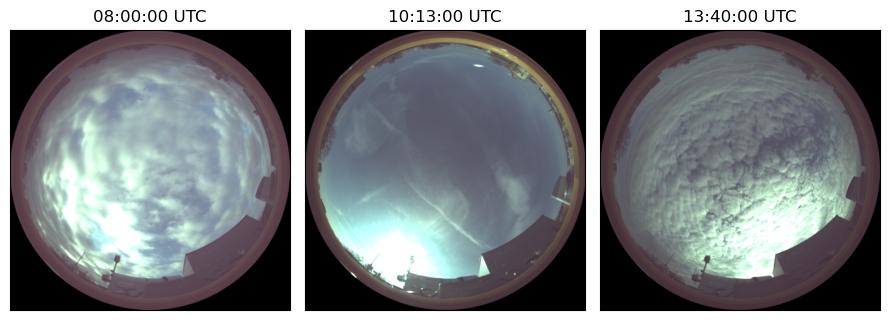

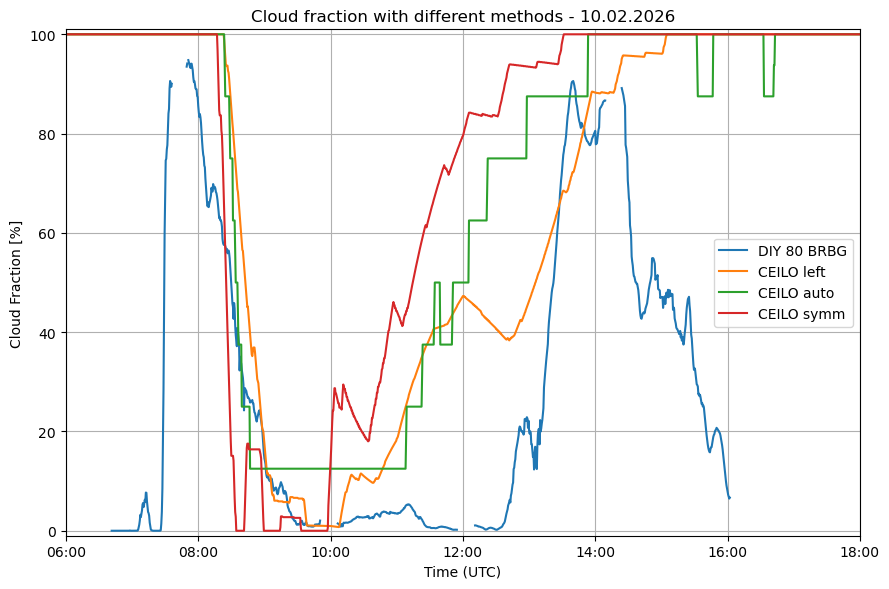

In [5]:
selday = dt.datetime(2026,2,10)

plot_range = [dt.datetime(2026,2,10,6,0,0), dt.datetime(2026,2,10,18,0,0)]

root_dir = "/projekt1/ag_maahn/data_obs/lim/allsky1/images/2026/02/10/"

gallery_02_10 = [root_dir + "08/20260210_080000.png",
                 root_dir + "10/20260210_101300.png",
                 root_dir + "13/20260210_134000.png"]

create_gallery(gallery_02_10)

plot_day(selday, ["diy_80_brbg", "cei_own_left", "cei_own_symm", "cei_auto_left"], plot_range, "fractions_20260210.png")

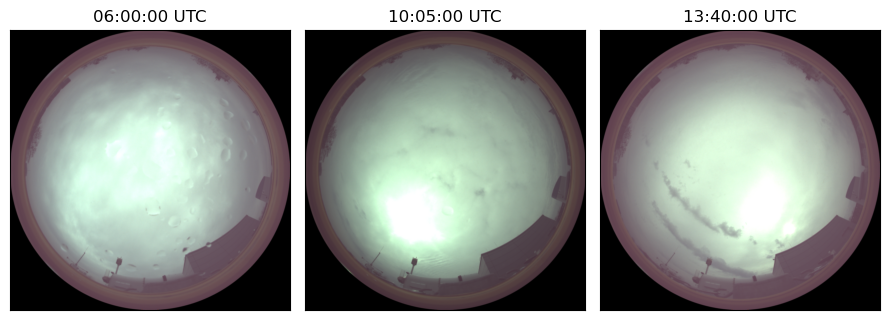

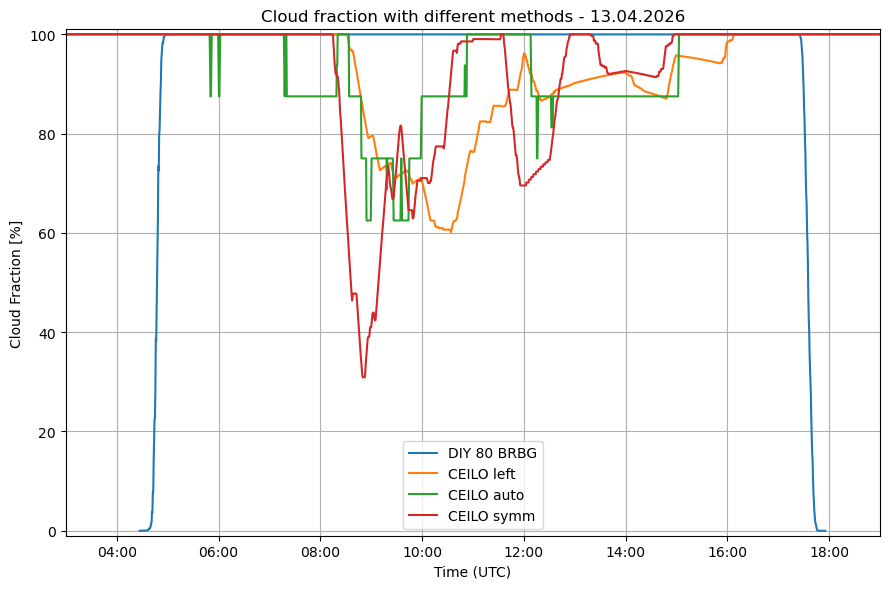

In [6]:
selday = dt.datetime(2026,4,13)

plot_range = [dt.datetime(2026,4,13,3,0,0), dt.datetime(2026,4,13,19,0,0)]

root_dir = "/projekt1/ag_maahn/data_obs/lim/allsky1/images/2026/04/13/"

gallery_04_13 = [root_dir + "06/20260413_060000.png",
                 root_dir + "10/20260413_100500.png",
                 root_dir + "13/20260413_134000.png"]

create_gallery(gallery_04_13)

plot_day(selday, ["diy_80_brbg", "cei_own_left", "cei_own_symm", "cei_auto_left"], plot_range, "fractions_20260413.png")

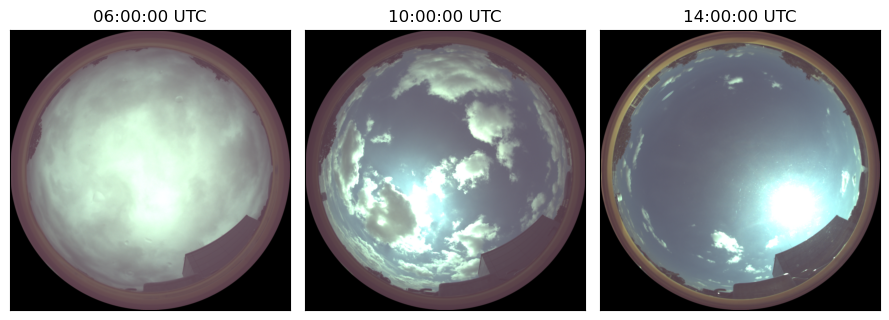

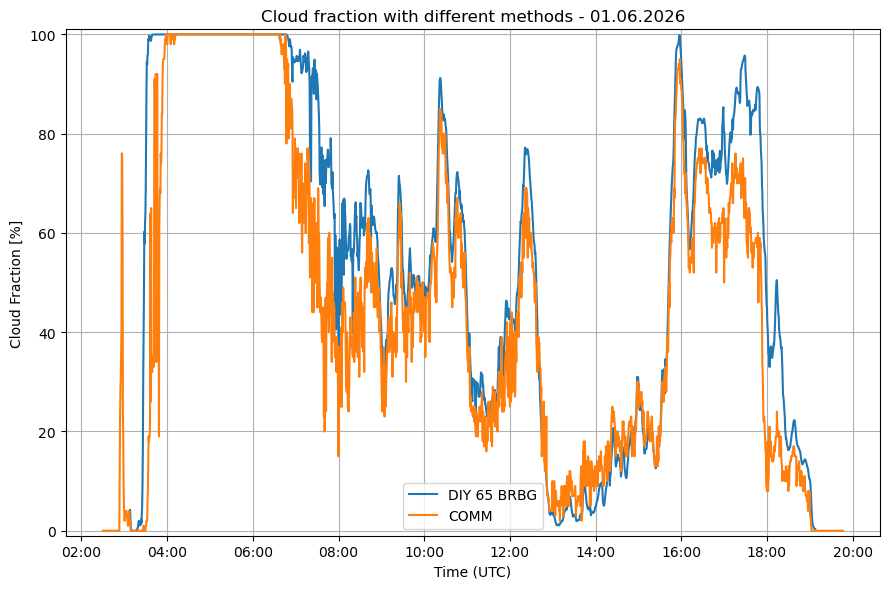

In [7]:
selday = dt.datetime(2026,6,1)

plot_range = [dt.datetime(2026,6,1,3,0,0), dt.datetime(2026,6,1,19,0,0)]

root_dir = "/projekt1/ag_maahn/data_obs/lim/allsky1/images/2026/06/01/"

gallery_04_13 = [root_dir + "06/20260601_060000.png",
                 root_dir + "10/20260601_100000.png",
                 root_dir + "14/20260601_140000.png"]

create_gallery(gallery_04_13, remap=False)

plot_day(selday, ["diy_65_brbg", "comm"], -1, "fractions_20260601.png")

/home/sdoeding/.conda/envs/myenv/lib/python3.14/site-packages/numpy/_core/numeric.py:386: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(a, fill_value, casting='unsafe')


(1520, 1520)


/tmp/ipykernel_3099364/2331277627.py:11: RuntimeWarning: invalid value encountered in cast
  raw_layer1 = cpl.calc_fractions(path1, mask_new, mappings, duplicates)[-1].astype("uint8")
/tmp/ipykernel_3099364/2331277627.py:12: RuntimeWarning: invalid value encountered in cast
  raw_layer2 = cpl.calc_fractions(path2, mask_new, mappings, duplicates)[-1].astype("uint8")


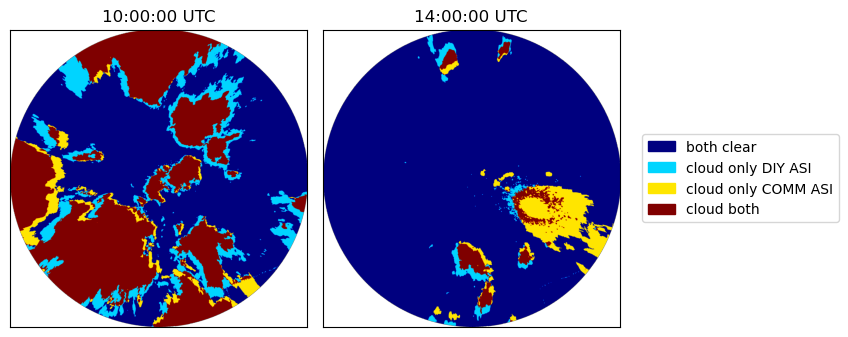

In [15]:
mask_new = cpl.prepare_mask("/home/sdoeding/analysis_scripts/auxiliary/mask_new.png")
mappings = cpl.calc_mappings(95, 65, 1520, "equidistant")
duplicates = cpl.prepare_duplicates("/home/sdoeding/analysis_scripts/auxiliary/duplicates_out.csv")
circle_mask = cv2.circle(np.full((1520,1520), np.nan, dtype="uint8"), (760,760), 760, (255), -1)

path1 = "/projekt1/ag_maahn/data_obs/lim/allsky1/images/2026/06/01/10/20260601_100000.png"
path2 = "/projekt1/ag_maahn/data_obs/lim/allsky1/images/2026/06/01/14/20260601_140000.png"

print(circle_mask.shape)

raw_layer1 = cpl.calc_fractions(path1, mask_new, mappings, duplicates)[-1].astype("uint8")
raw_layer2 = cpl.calc_fractions(path2, mask_new, mappings, duplicates)[-1].astype("uint8")

cld_brbg_layer1 = np.where(circle_mask==255, raw_layer1, np.nan)
cld_brbg_layer2 = np.where(circle_mask==255, raw_layer2, np.nan)

cv2rotator = cv2.getRotationMatrix2D((760,760), 9, 1.0)

cld_brbg_layer1 = cv2.warpAffine(cld_brbg_layer1, cv2rotator, (1520,1520))
cld_brbg_layer2 = cv2.warpAffine(cld_brbg_layer2, cv2rotator, (1520,1520))

cld_comm_layer1 = cv2.flip(cv2.resize(cv2.imread("commASI_20260601_100000.png", -1) // 255, (1520,1520), cv2.INTER_LINEAR), 1)
cld_comm_layer2 = cv2.flip(cv2.resize(cv2.imread("commASI_20260601_140000.png", -1) // 255, (1520,1520), cv2.INTER_LINEAR), 1)

cld_comm_layer1 = np.where(circle_mask==255, cld_comm_layer1, np.nan)
cld_comm_layer2 = np.where(circle_mask==255, cld_comm_layer2, np.nan)

# fig, ax = plt.subplots(nrows=2, ncols=2, tight_layout=True)

# ax[0,0].imshow(cld_brbg_layer1)
# ax[0,1].imshow(cld_brbg_layer2)
# ax[1,0].imshow(cld_comm_layer1)
# ax[1,1].imshow(cld_comm_layer2)

composite1 = cld_brbg_layer1 + 2*cld_comm_layer1
composite2 = cld_brbg_layer2 + 2*cld_comm_layer2

########################################

values = [0,1,2,3]
labels=["both clear", "cloud only DIY ASI", "cloud only COMM ASI", "cloud both"]

fig, ax =plt.subplots(nrows=1, ncols=2, tight_layout=True)

im1 = ax[0].imshow(composite1, cmap="jet")
cols1 = [im1.cmap(im1.norm(value)) for value in values]
patches1 = [ mpl.patches.Patch(color=cols1[i], label=labels[i]) for i in range(len(values)) ]
ax[0].set_xticks([],[])
ax[0].set_yticks([],[])
ax[0].set_title("10:00:00 UTC")

im2 = ax[1].imshow(composite2, cmap="jet")
cols2 = [im2.cmap(im2.norm(value)) for value in values]
patches2 = [ mpl.patches.Patch(color=cols2[i], label=labels[i]) for i in range(len(values)) ]
ax[1].set_xticks([],[])
ax[1].set_yticks([],[])
ax[1].set_title("14:00:00 UTC")

fig.legend(handles=patches1, bbox_to_anchor=(1, 0.5), loc="center left")
fig.savefig("cld_diy_comm_20260601.png", bbox_inches='tight')

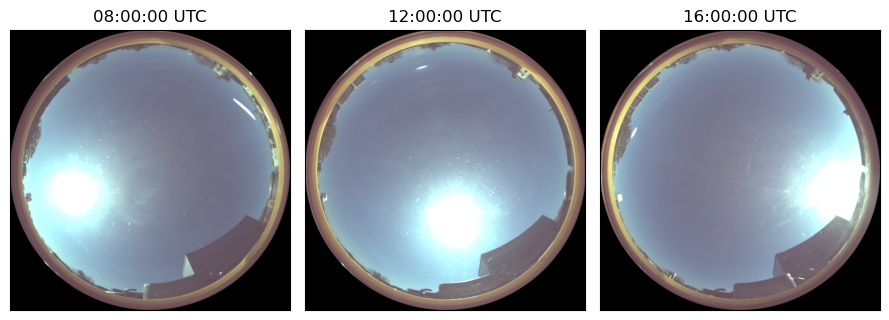

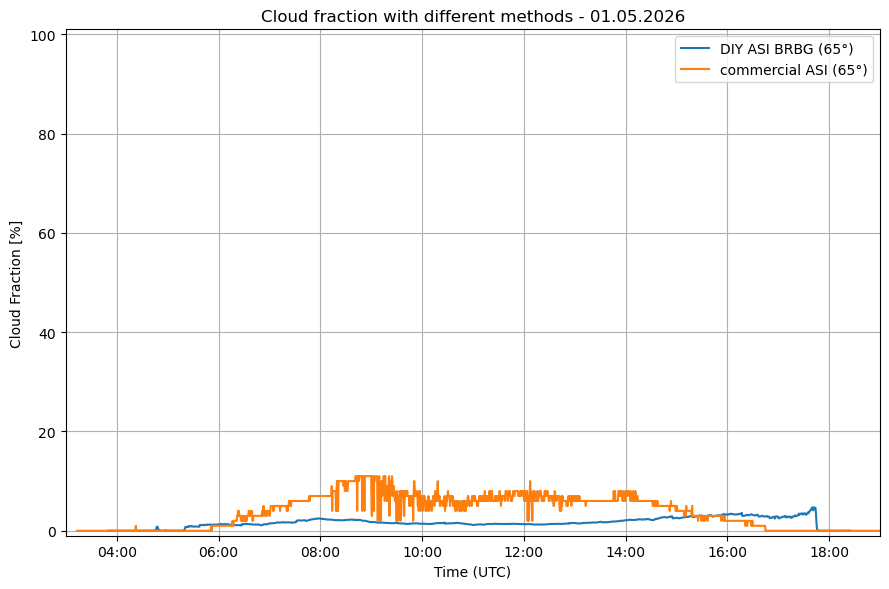

In [10]:
selday = dt.datetime(2026,5,1)

plot_range = [dt.datetime(2026,5,1,3,0,0), dt.datetime(2026,5,1,19,0,0)]

root_dir = "/projekt1/ag_maahn/data_obs/lim/allsky1/images/2026/05/01/"

gallery_02_10 = [root_dir + "08/20260501_080000.png",
                 root_dir + "12/20260501_120000.png",
                 root_dir + "16/20260501_160000.png"]

create_gallery(gallery_02_10)

plot_day(selday, ["diy_65_brbg", "comm"], plot_range, "fractions_20260501.png")

/home/sdoeding/.conda/envs/myenv/lib/python3.14/site-packages/numpy/_core/numeric.py:386: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(a, fill_value, casting='unsafe')
/tmp/ipykernel_1132367/573765173.py:9: RuntimeWarning: invalid value encountered in cast
  raw_layer1 = cpl.calc_fractions(path1, mask_new, mappings, duplicates)[-1].astype("uint8")


(1520, 1520)


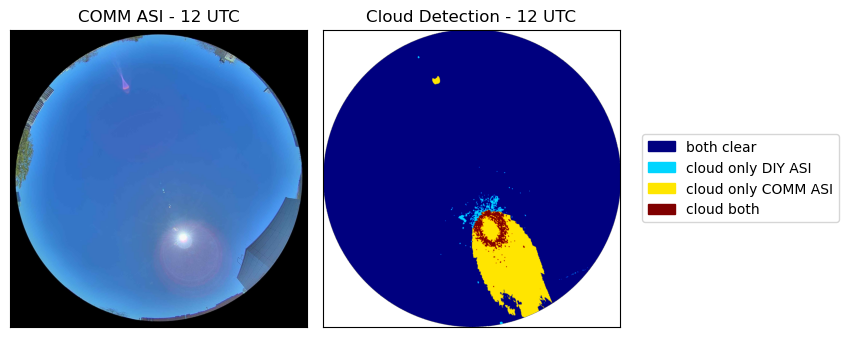

In [3]:
mask_new = cpl.prepare_mask("/home/sdoeding/analysis_scripts/auxiliary/mask_new.png")
mappings = cpl.calc_mappings(95, 65, 1520, "equidistant")
duplicates = cpl.prepare_duplicates("/home/sdoeding/analysis_scripts/auxiliary/duplicates_out.csv")
circle_mask = cv2.circle(np.full((1520,1520), np.nan, dtype="uint8"), (760,760), 760, (255), -1)

path1 = "/projekt1/ag_maahn/data_obs/lim/allsky1/images/2026/05/01/12/20260501_120000.png"


raw_layer1 = cpl.calc_fractions(path1, mask_new, mappings, duplicates)[-1].astype("uint8")

cld_brbg_layer1 = np.where(circle_mask==255, raw_layer1, np.nan)

cv2rotator = cv2.getRotationMatrix2D((760,760), 9, 1.0)

cld_brbg_layer1 = cv2.warpAffine(cld_brbg_layer1, cv2rotator, (1520,1520))


cld_comm_layer1 = cv2.flip(cv2.resize(cv2.imread("commASI_20260501_120000.png", -1) // 255, (1520,1520), cv2.INTER_LINEAR), 1)
print(cld_comm_layer1.shape)

cld_comm_layer1 = np.where(circle_mask==255, cld_comm_layer1, np.nan)

composite1 = cld_brbg_layer1 + 2*cld_comm_layer1

comm_img = np.flip(cv2.imread("commASI_orig_20260501_120000.png"), axis=2)

########################################

values = [0,1,2,3]
labels=["both clear", "cloud only DIY ASI", "cloud only COMM ASI", "cloud both"]

fig, ax =plt.subplots(nrows=1, ncols=2, tight_layout=True)

ax[0].imshow(comm_img)
ax[0].set_xticks([],[])
ax[0].set_yticks([],[])
ax[0].set_title("COMM ASI - 12 UTC")

im1 = ax[1].imshow(composite1, cmap="jet")
cols1 = [im1.cmap(im1.norm(value)) for value in values]
patches1 = [ mpl.patches.Patch(color=cols1[i], label=labels[i]) for i in range(len(values)) ]
ax[1].set_xticks([],[])
ax[1].set_yticks([],[])
ax[1].set_title("Cloud Detection - 12 UTC")


fig.legend(handles=patches1, bbox_to_anchor=(1, 0.5), loc="center left")
fig.savefig("cld_diy_comm_20260501.png", bbox_inches='tight')